# Análisis del Dataset_Balanceado_700

Este script cuenta cuántas imágenes hay por cada clase en el dataset `Dataset_Balanceado_700` y verifica sus dimensiones. 
Dado que los archivos son `.npz`, se itera sobre todos los archivos, se cargan y se suman las imágenes contenidas en cada uno.

In [5]:
import os
import numpy as np

# Ruta del dataset
dataset_path = 'Dataset_Balanceado_700'

if not os.path.exists(dataset_path):
    # Ajuste de ruta si se corre desde Propuesta1/
    if os.path.exists('../Dataset_Balanceado_700'):
        dataset_path = '../Dataset_Balanceado_700'
    else:
        print(f"Error: La carpeta '{dataset_path}' no se encuentra en el directorio actual.")

if os.path.exists(dataset_path):
    # Obtener las carpetas de las clases
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    
    print(f"{'Clase':<25} | {'Archivos':<10} | {'Total Imágenes':<15} | {'Dimensiones (WxH)':<20}")
    print("-" * 80)
    
    total_dataset_images = 0
    
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_dir) if f.lower().endswith('.npz')]
        
        num_files = len(files)
        total_class_images = 0
        dims_set = set()
        
        for file_name in files:
            file_path = os.path.join(class_dir, file_name)
            try:
                with np.load(file_path) as data:
                    # Basado en la salida anterior, la clave es 'imagenes'
                    if 'imagenes' in data:
                        imgs = data['imagenes']
                        # Asumimos formato (N, H, W) donde N es el numero de imagenes
                        n_imgs = imgs.shape[0]
                        total_class_images += n_imgs
                        
                        if len(imgs.shape) >= 3:
                             dims_set.add(f"{imgs.shape[2]}x{imgs.shape[1]}") # WxH
                    else:
                        # Si no encuentra 'imagenes', intentar listar claves disponibles
                        print(f"Advertencia: 'imagenes' no encontrado en {file_name}. Claves: {list(data.files)}")

            except Exception as e:
                print(f"Error leyendo {file_name}: {e}")

        total_dataset_images += total_class_images
        
        dims_summary = ", ".join(list(dims_set)) if dims_set else "N/A"
        
        print(f"{class_name:<25} | {num_files:<10} | {total_class_images:<15} | {dims_summary:<20}")

    print("-" * 80)
    print(f"Total de imágenes en el dataset: {total_dataset_images}")

Clase                     | Archivos   | Total Imágenes  | Dimensiones (WxH)   
--------------------------------------------------------------------------------
Adenoma_hipofisario       | 62         | 699             | 128x128             
Glioma                    | 89         | 699             | 128x128             
Meningioma                | 82         | 700             | 128x128             
--------------------------------------------------------------------------------
Total de imágenes en el dataset: 2098


# Implementación de CNN Cuántica con Validación Cruzada Estratificada (5-Fold)

En esta sección se implementa el flujo de trabajo completo:
1. **Preprocesamiento Cuántico**: Se aplica convolución cuántica a las imágenes.
2. **División de Datos**: Se respeta la estructura de pacientes (archivos .npz) para evitar data leakage. Se separa un 15% para Test y el resto para 5-Fold CV.
3. **Entrenamiento**: Se entrena una Red Neuronal (MLP) sobre las características cuánticas.
4. **Evaluación**: Se reportan métricas de rendimiento.

In [6]:
# --- 5-FOLD CROSS VALIDATION STRATIFIED ---
BATCH_SIZE = 32
EPOCHS = 50
N_SPLITS = 5

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS)

fold_metrics = []
history_per_fold = []

print(f"Iniciando {N_SPLITS}-Fold Cross Validation...")
profiler = Profiler()
profiler.start()

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_val, y_train_val, groups_train_val)):
    print(f"\nFold {fold+1}/{N_SPLITS}")
    
    X_f_train, y_f_train = X_train_val[train_idx], y_train_val[train_idx]
    X_f_val, y_f_val = X_train_val[val_idx], y_train_val[val_idx]
    
    train_ds = TensorDataset(X_f_train, y_f_train)
    val_ds = TensorDataset(X_f_val, y_f_val)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    input_shape = X_all.shape[1:]
    model = RedNeuronalGeneral(input_shape=input_shape, num_classes=3).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        
        model.eval()
        val_loss = 0.0
        all_val_preds = []
        all_val_labels = []
        all_val_probs = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                probs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs.data, 1)
                
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                all_val_probs.extend(probs.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        metrics = calculate_metrics(all_val_labels, all_val_preds, all_val_probs)
        val_accuracy = metrics['accuracy'] * 100
        
        fold_history['train_loss'].append(avg_train_loss)
        fold_history['val_loss'].append(avg_val_loss)
        fold_history['val_acc'].append(val_accuracy)
        
        if(epoch % 10 == 0):
            print(f"  Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
    
    print(f"  Final Val Acc Fold {fold+1}: {fold_history['val_acc'][-1]:.2f}%")
    history_per_fold.append(fold_history)
    fold_metrics.append(fold_history['val_acc'][-1])

elapsed, (ram, gpu) = profiler.get_elapsed(), profiler.get_memory_usage()
print("\n--- Resultados Cross-Validation ---")
print(f"Accuracy promedio: {np.mean(fold_metrics):.2f}% +/- {np.std(fold_metrics):.2f}%")
print(f"Entrenamiento completado en {elapsed:.2f}s. RAM: {ram:.2f}GB, GPU: {gpu:.2f}MB")

Usando dispositivo de entrenamiento (Red Neuronal): cpu


In [8]:
# Inicializar Profiler y QuantumProcessor
profiler = Profiler()
q_processor = QuantumProcessor()
dataset_path = '../../Codigo/Dataset_Balanceado_700'

print("Cargando datos y procesando características cuánticas...")
profiler.start()

X, y, groups = load_balanced_data(dataset_path)

X_q = []
cache_dir = '../../maestro/cache/propuesta1'
for img in tqdm(X, desc="Procesamiento Cuántico (P1)"):
    # Propuesta 1 usa proposal_id=1
    q_map = q_processor.process(img, proposal_id=1, cache_dir=cache_dir)
    X_q.append(q_map)

X_all = torch.tensor(np.array(X_q), dtype=torch.float32).unsqueeze(1) # (N, 1, H, W)
y_all = torch.tensor(y, dtype=torch.long)
groups_all = np.array(groups)

elapsed, (ram, gpu) = profiler.get_elapsed(), profiler.get_memory_usage()
print(f"Carga y Procesamiento completado en {elapsed:.2f}s. RAM: {ram:.2f}GB, GPU: {gpu:.2f}MB")

print(f"\nProcesamiento Completado.")
print(f"X shape: {X_all.shape}")
print(f"y shape: {y_all.shape}")
print(f"Grupos (Pacientes): {len(np.unique(groups_all))} únicos.")

In [ ]:
# --- ESTRATEGIA DE DIVISIÓN DE DATOS ---
# 1. Separar Test Set (15% de PACIENTES) preservando estratificación
#    Primero identificamos etiquetas por paciente para estratificar
unique_patients, patient_indices = np.unique(groups_all, return_index=True)
patient_labels = y_all[patient_indices].numpy()

train_val_patients, test_patients = train_test_split(unique_patients, 
                                                    test_size=0.15, 
                                                    stratify=patient_labels,
                                                    random_state=42)

print(f"Total Pacientes: {len(unique_patients)}")
print(f"Pacientes Train/Val: {len(train_val_patients)}")
print(f"Pacientes Test: {len(test_patients)}")

# Crear máscaras booleanas para filtrar X_all y y_all
# np.isin verifica si cada elemento de groups_all está en la lista de pacientes
mask_train_val = np.isin(groups_all, train_val_patients)
mask_test = np.isin(groups_all, test_patients)

X_train_val = X_all[mask_train_val]
y_train_val = y_all[mask_train_val]
groups_train_val = groups_all[mask_train_val]

X_test = X_all[mask_test]
y_test = y_all[mask_test]

print(f"Imágenes Train/Val: {len(X_train_val)}")
print(f"Imágenes Test: {len(X_test)}")

Total Pacientes: 233
Pacientes Train/Val: 198
Pacientes Test: 35
Imágenes Train/Val: 1770
Imágenes Test: 328


In [ ]:
# --- 5-FOLD CROSS VALIDATION STRATIFIED ---
BATCH_SIZE = 32
EPOCHS = 50
N_SPLITS = 5

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS)

fold_metrics = []
history_per_fold = []

print(f"Iniciando {N_SPLITS}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_val, y_train_val, groups_train_val)):
    print(f"\nFold {fold+1}/{N_SPLITS}")
    
    # Crear datasets para el fold actual
    # Convertir a Tensores si no lo son
    X_f_train, y_f_train = X_train_val[train_idx], y_train_val[train_idx]
    X_f_val, y_f_val = X_train_val[val_idx], y_train_val[val_idx]
    
    train_ds = TensorDataset(X_f_train, y_f_train)
    val_ds = TensorDataset(X_f_val, y_f_val)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Inicializar Modelo
    # Input shape: (C, H, W)
    input_shape = X_all.shape[1:]
    model = RedNeuronalGeneral(input_shape=input_shape, num_classes=3).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # Historial para graficar
    fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(EPOCHS):
        # Train
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val
        
        fold_history['train_loss'].append(avg_train_loss)
        fold_history['val_loss'].append(avg_val_loss)
        fold_history['val_acc'].append(val_accuracy)
        
        if(epoch % 10 == 0):
            print(f"  Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
    
    print(f"  Final Val Acc Fold {fold+1}: {fold_history['val_acc'][-1]:.2f}%")
    history_per_fold.append(fold_history)
    fold_metrics.append(fold_history['val_acc'][-1])

print("\n--- Resultados Cross-Validation ---")
print(f"Accuracy promedio: {np.mean(fold_metrics):.2f}% +/- {np.std(fold_metrics):.2f}%")

Iniciando 5-Fold Cross Validation...

Fold 1/5
  Epoch 1: Train Loss: 0.5114 | Val Acc: 84.18%
  Epoch 11: Train Loss: 0.0154 | Val Acc: 79.38%
  Epoch 21: Train Loss: 0.0166 | Val Acc: 82.20%
  Epoch 31: Train Loss: 0.0037 | Val Acc: 82.20%
  Epoch 41: Train Loss: 0.0047 | Val Acc: 79.38%
  Final Val Acc Fold 1: 82.20%

Fold 2/5
  Epoch 1: Train Loss: 0.5053 | Val Acc: 84.75%
  Epoch 11: Train Loss: 0.0204 | Val Acc: 83.62%
  Epoch 21: Train Loss: 0.0165 | Val Acc: 80.23%
  Epoch 31: Train Loss: 0.0067 | Val Acc: 79.66%
  Epoch 41: Train Loss: 0.0048 | Val Acc: 82.20%
  Final Val Acc Fold 2: 80.79%

Fold 3/5
  Epoch 1: Train Loss: 0.5086 | Val Acc: 82.25%
  Epoch 11: Train Loss: 0.0343 | Val Acc: 81.13%
  Epoch 21: Train Loss: 0.0126 | Val Acc: 82.82%
  Epoch 31: Train Loss: 0.0115 | Val Acc: 83.94%
  Epoch 41: Train Loss: 0.0055 | Val Acc: 84.79%
  Final Val Acc Fold 3: 84.23%

Fold 4/5
  Epoch 1: Train Loss: 0.5098 | Val Acc: 83.05%
  Epoch 11: Train Loss: 0.0209 | Val Acc: 81.64%
 

# Validación Leave-One-Subject-Out (LOSO)

Adicionalmente a la validación cruzada 5-fold, a continuación se realiza la validación **Leave-One-Subject-Out (LOSO)**.
En este esquema, en cada iteración se deja un paciente completo (todas sus imágenes) de los datos de entrenamiento como conjunto de validación, y se entrena con el resto.


In [ ]:
# --- LEAVE-ONE-SUBJECT-OUT (LOSO) CROSS VALIDATION ---
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
loso_fold_metrics = []

n_splits_loso = logo.get_n_splits(X_train_val, y_train_val, groups_train_val)
print(f"Iniciando Leave-One-Subject-Out (LOSO) Cross Validation con {n_splits_loso} pacientes...")

for fold, (train_idx, val_idx) in enumerate(logo.split(X_train_val, y_train_val, groups_train_val)):
    X_f_train, y_f_train = X_train_val[train_idx], y_train_val[train_idx]
    X_f_val, y_f_val = X_train_val[val_idx], y_train_val[val_idx]
    
    train_ds = TensorDataset(X_f_train, y_f_train)
    val_ds = TensorDataset(X_f_val, y_f_val)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = RedNeuronalGeneral(input_shape=X_all.shape[1:], num_classes=3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_val_preds = []
    all_val_labels = []
    all_val_probs = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            all_val_probs.extend(probs.cpu().numpy())
            
    metrics = calculate_metrics(all_val_labels, all_val_preds, all_val_probs)
    val_accuracy = metrics['accuracy'] * 100
    loso_fold_metrics.append(val_accuracy)
    
    if (fold + 1) % 10 == 0 or (fold + 1) == n_splits_loso:
        print(f"  Completado LOSO Fold {fold+1}/{n_splits_loso} | Val Acc del fold: {val_accuracy:.2f}%")

print("\n--- Resultados Leave-One-Subject-Out (LOSO) ---")
print(f"Accuracy promedio LOSO: {np.mean(loso_fold_metrics):.2f}% +/- {np.std(loso_fold_metrics):.2f}%")

Iniciando Leave-One-Subject-Out (LOSO) Cross Validation con 198 pacientes...
  Completado LOSO Fold 10/198 | Val Acc del fold: 50.00%
  Completado LOSO Fold 20/198 | Val Acc del fold: 84.62%
  Completado LOSO Fold 30/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 40/198 | Val Acc del fold: 58.33%
  Completado LOSO Fold 50/198 | Val Acc del fold: 12.50%
  Completado LOSO Fold 60/198 | Val Acc del fold: 50.00%
  Completado LOSO Fold 70/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 80/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 90/198 | Val Acc del fold: 95.24%
  Completado LOSO Fold 100/198 | Val Acc del fold: 50.00%
  Completado LOSO Fold 110/198 | Val Acc del fold: 33.33%
  Completado LOSO Fold 120/198 | Val Acc del fold: 90.00%
  Completado LOSO Fold 130/198 | Val Acc del fold: 44.44%
  Completado LOSO Fold 140/198 | Val Acc del fold: 86.67%
  Completado LOSO Fold 150/198 | Val Acc del fold: 90.00%
  Completado LOSO Fold 160/198 | Val Acc del fold: 100.00%


In [ ]:
# --- VISUALIZACIÓN DE PÉRDIDAS (LOSS) ---
plt.figure(figsize=(12, 6))

for i, history in enumerate(history_per_fold):
    plt.plot(history['train_loss'], linestyle='--', label=f'Fold {i+1} Train')
    plt.plot(history['val_loss'], label=f'Fold {i+1} Val')

plt.title('Training & Validation Loss per Fold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


--- Entrenando Modelo Final en todo Train+Val para evaluar en Test ---


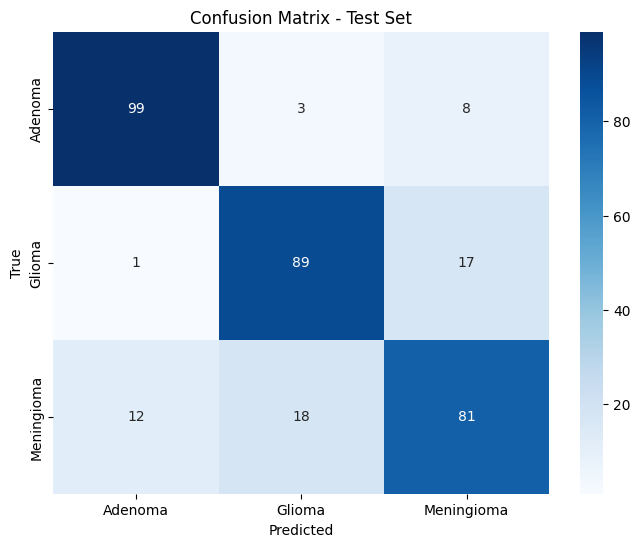


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

     Adenoma       0.88      0.90      0.89       110
      Glioma       0.81      0.83      0.82       107
  Meningioma       0.76      0.73      0.75       111

    accuracy                           0.82       328
   macro avg       0.82      0.82      0.82       328
weighted avg       0.82      0.82      0.82       328



In [ ]:
# --- EVALUACIÓN FINAL EN TEST SET ---
print("\n--- Entrenando Modelo Final en todo Train+Val para evaluar en Test ---")

full_train_ds = TensorDataset(X_train_val, y_train_val)
full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_ds = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

final_model = RedNeuronalGeneral(input_shape=X_all.shape[1:], num_classes=3).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    final_model.train()
    for inputs, labels in full_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

final_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

metrics = calculate_metrics(all_labels, all_preds, all_probs)
print(f"\nMétricas Finales en Test:")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 Macro: {metrics['f1_macro']:.4f}")
print(f"AUC: {metrics['auc']:.4f}")

# --- MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Adenoma', 'Glioma', 'Meningioma']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()

print("\n--- Classification Report (Test Set) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))